In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
sale=pd.read_csv('C:/Users/user/Downloads/Amazon.csv')

In [7]:
sale.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000



# Total OrderID count 



In [9]:
a=sale['OrderID'].count()
a
print('Total order count :',a)


Total order count : 100000


Q3: Total unique কতজন customer আছে বের করো
# CustomerID unique count

ount কত বের করো
# Discount max

In [10]:
a=sale['CustomerID'].value_counts()
a

CustomerID
CUST023748    10
CUST037103    10
CUST042938     9
CUST009614     9
CUST034288     9
              ..
CUST007324     1
CUST002460     1
CUST044619     1
CUST045257     1
CUST031254     1
Name: count, Length: 43233, dtype: int64


# Find unique values of the Category column


In [16]:
sale['Category'].value_counts().sort_values(ascending=False).reset_index()

,Category,count
0,Electronics,16853
1,Sports & Outdoors,16804
2,Books,16752
3,Home & Kitchen,16610
4,Toys & Games,16542
5,Clothing,16439



# PaymentMethod unique values



In [15]:
sale['PaymentMethod'].value_counts().sort_values(ascending=False).reset_index()

,PaymentMethod,count
0,Credit Card,35038
1,Debit Card,20024
2,UPI,15066
3,Amazon Pay,15017
4,Net Banking,9927
5,Cash on Delivery,4928


# Calculate the total sales amount.


In [13]:
a=sale['TotalAmount'].sum()
print('Total sales amount :',a)

Total sales amount : 91825647.92


# Calculate the  Average order value 



In [14]:
a=sale['TotalAmount'].mean()
print('Average order value :',a)

Average order value : 918.2564792000001



# Find the most expensive product.


In [15]:
a=sale['TotalAmount'].max()
print('max order value :',a)

max order value : 3534.98



# Calculate the total quantity sold.


In [17]:
a=sale['Quantity'].sum()
print('total order value :',a)
print('Total quantity sold is calculated by summing the Quantity column')

total order value : 300140
Total quantity sold is calculated by summing the Quantity column


# Maximum disc

In [17]:
a=sale['Discount'].max()
print('max Discount :',a)

max Discount : 0.3


# Calculate total sales by category.


Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64
Total sales per category are calculated by grouping Category and summing TotalAmount.


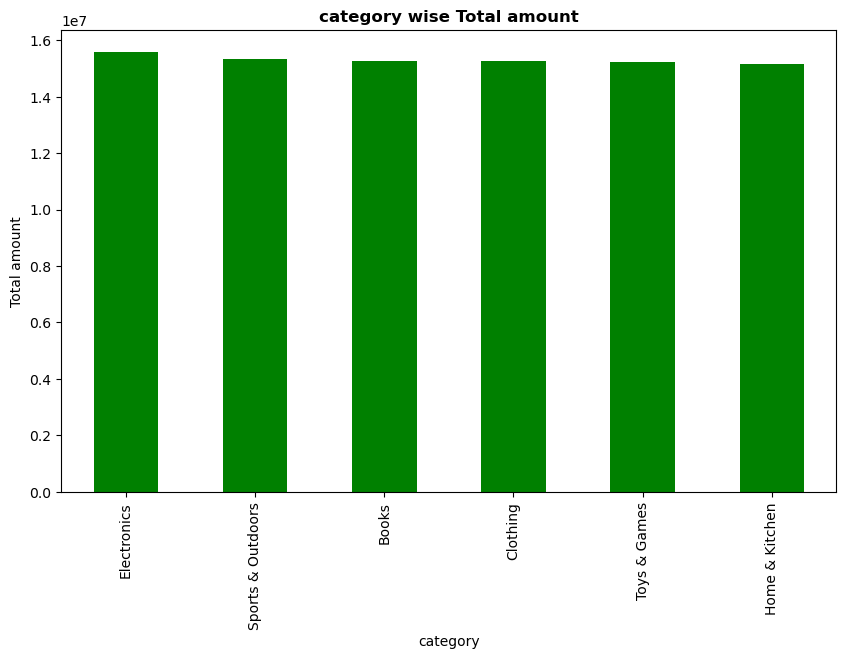

In [18]:
group=sale.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print(group)
print('Total sales per category are calculated by grouping Category and summing TotalAmount.')
plt.figure(figsize=(10,6))
group.plot(kind='bar',color='green')
plt.xlabel('category')
plt.ylabel('Total amount')
plt.title('category wise Total amount',color='black',fontweight='bold')
plt.show()


# Calculate total quantity sold by brand.

Brand
Apex          29955
BrightLux     29616
CoreTech      30430
FitLife       30121
HomeEase      29476
KiddoFun      30168
NexPro        29791
ReadMore      30421
UrbanStyle    30104
Zenith        30058
Name: Quantity, dtype: int64
"Total quantity per brand is calculated by grouping Brand and summing Quantity.


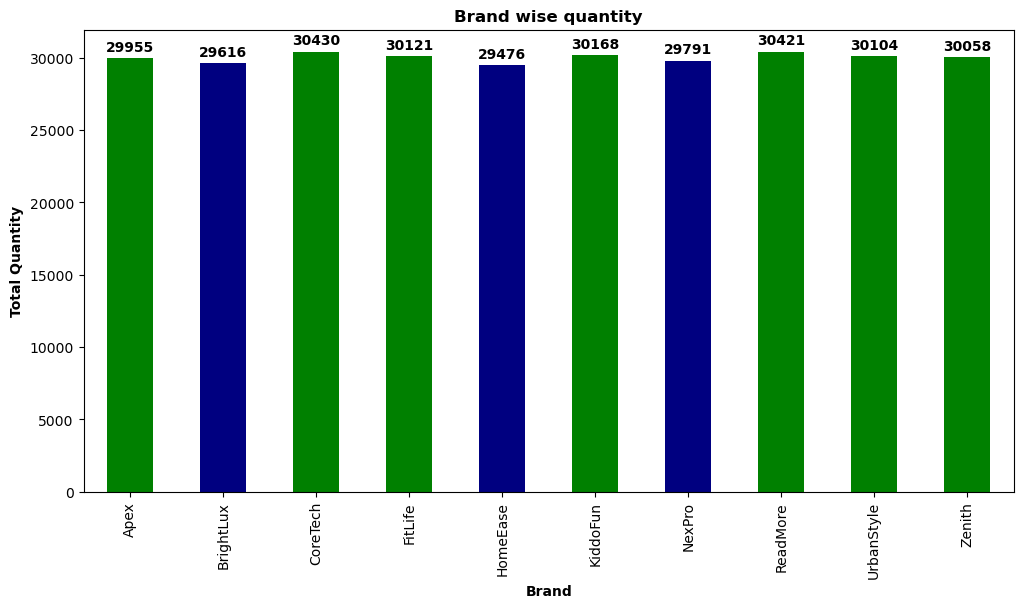

In [19]:
group=sale.groupby('Brand')['Quantity'].sum()
print(group)
print('"Total quantity per brand is calculated by grouping Brand and summing Quantity.')
plt.figure(figsize=(12,6))
colors=['green' if x>29800 else 'navy'
    for x in group]
ax=group.plot(kind='bar',color=colors)
plt.xlabel('Brand',color='black',fontweight='bold')
plt.ylabel('Total Quantity',color='black',fontweight='bold')
plt.title('Brand wise quantity',color='black',fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold')
plt.show()



# Calculate total orders by city.


Total orders per city are calculated by grouping City and counting OrderID City
Austin           5043
Charlotte        5110
Chicago          5020
Columbus         5021
Dallas           5105
Denver           4991
Fort Worth       4934
Houston          4901
Indianapolis     4970
Jacksonville     5107
Los Angeles      5058
New York         4949
Philadelphia     5014
Phoenix          4941
San Antonio      4913
San Diego        4826
San Francisco    4930
San Jose         5107
Seattle          5039
Washington       5021
Name: OrderID, dtype: int64


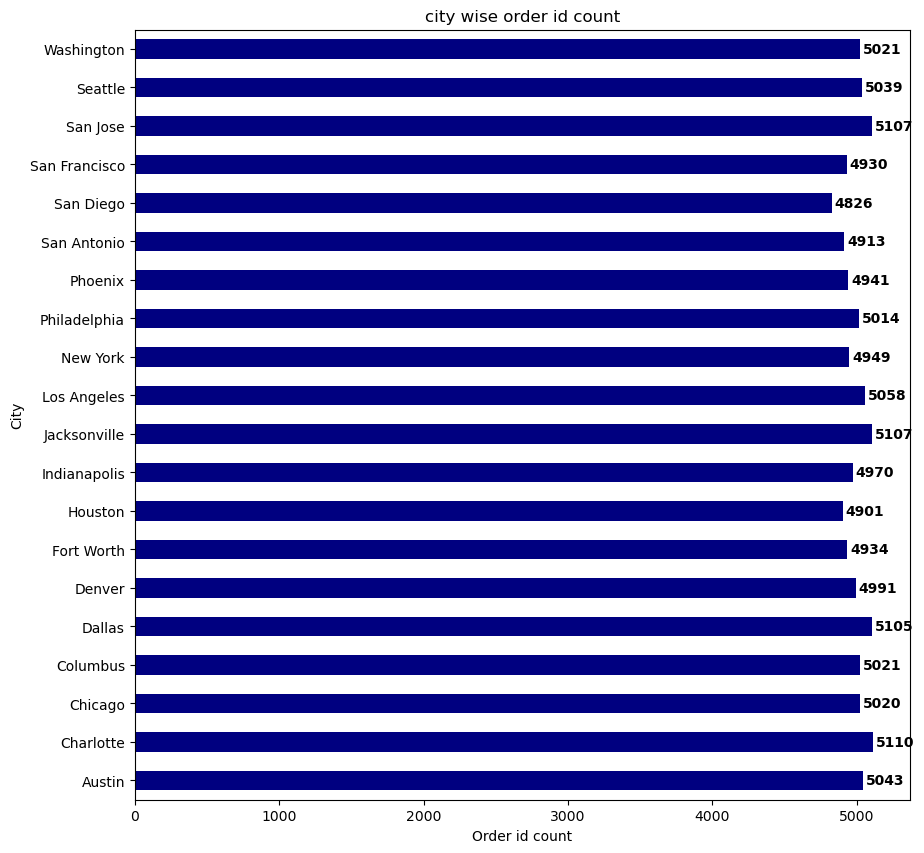

In [20]:
group=sale.groupby('City')['OrderID'].count()
print('Total orders per city are calculated by grouping City and counting OrderID',group)
plt.figure(figsize=(10,10))
ax=group.plot(kind='barh',color='navy')
plt.xlabel('Order id count')
plt.ylabel('City')
plt.title('city wise order id count')
for container in ax.containers:
    ax.bar_label(container,padding=2,color='black',fontweight='bold')


# Calculate total sales by payment method.

PaymentMethod
Amazon Pay          13697498.42
Cash on Delivery     4515609.16
Credit Card         32122158.69
Debit Card          18538678.53
Net Banking          9055674.57
UPI                 13896028.55
Name: TotalAmount, dtype: float64
"Total sales per payment method are calculated by grouping PaymentMethod and summing TotalAmount.


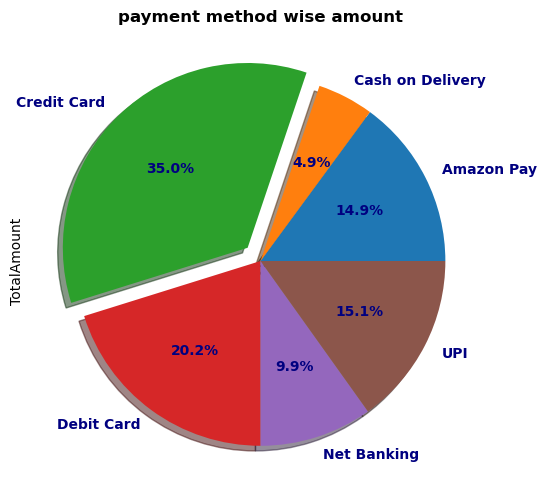

In [21]:
group=sale.groupby('PaymentMethod')['TotalAmount'].sum()
print(group)
print('"Total sales per payment method are calculated by grouping PaymentMethod and summing TotalAmount.')
plt.figure(figsize=(10,6))
ax=group.plot(kind='pie',autopct='%1.1f%%',explode=[0,0,0.1,0,0,0],shadow=True,textprops={'weight':'bold','color':'navy'})
plt.title('payment method wise amount',color = 'black',fontweight='bold')
plt.show()
    

# Calculate order count by order status



OrderStatus
Cancelled     3028
Delivered    74628
Pending       4103
Returned      3049
Shipped      15192
Name: OrderID, dtype: int64
Order counts per status are calculated by grouping OrderStatus and counting OrderID.


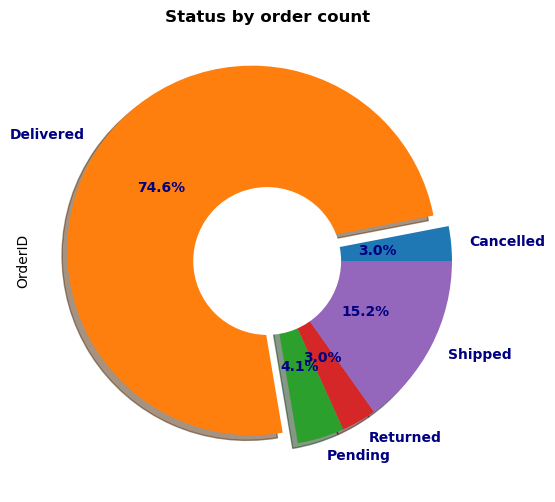

In [22]:
group=sale.groupby('OrderStatus')['OrderID'].count()
print(group)
print("Order counts per status are calculated by grouping OrderStatus and counting OrderID.")
plt.figure(figsize=(10,6))
group.plot(kind='pie',autopct='%1.1f%%',textprops={'weight':'bold','color':'navy'},explode=[0,0.1,0,0,0],shadow= True)
center=plt.Circle((0,0),0.40,fc='white')
fig=plt.gcf()
fig.gca().add_artist(center)
plt.title('Status by order count',color='black',fontweight='bold')
plt.show()

# Find the top 5 customers with the highest total purchase amount.



CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Name: TotalAmount, dtype: float64
Top 5 customers are determined by grouping CustomerName, summing TotalAmount, and sorting in descending order.


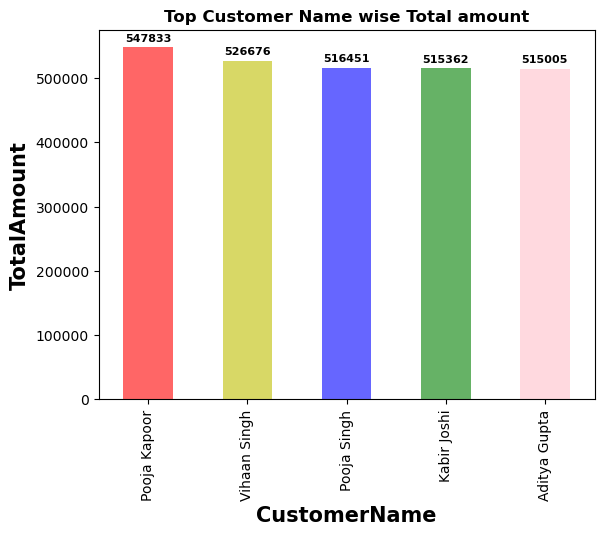

In [24]:
group=sale.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)
print(group)
print("Top 5 customers are determined by grouping CustomerName, summing TotalAmount, and sorting in descending order.")
c=['r','y','b','g','pink']
ax=group.plot(kind='bar',color=c,alpha=.6)
plt.title('Top Customer Name wise Total amount',color ='black',fontweight='bold')
plt.xlabel('CustomerName',color='black',fontweight='bold',fontsize=15)
plt.ylabel('TotalAmount',color='black',fontweight='bold',fontsize=15)
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold',fontsize=8)
plt.show()

#  Find the city with the highest total sales.



City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Name: TotalAmount, dtype: float64
The city with the highest sales is determined by grouping City, summing TotalAmount, and selecting the maximum.


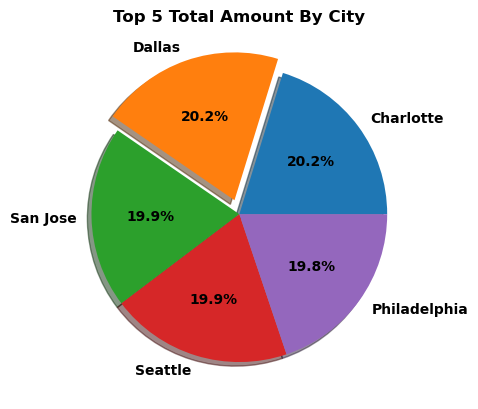

In [25]:
group=sale.groupby('City')['TotalAmount'].sum().sort_values(ascending=False).head(5)
print(group)
print("The city with the highest sales is determined by grouping City, summing TotalAmount, and selecting the maximum.")
group.plot(kind='pie',autopct='%1.1f%%',textprops={'weight':'bold','color':'black'},explode=[0,0.1,0,0,0],shadow=True)
plt.title('Top 5 Total Amount By City',color='black',fontweight='bold')
plt.ylabel('')
plt.show()

# Identify the order with the highest shipping cost.

In [31]:
sale.loc[sale['ShippingCost'].idxmax()]
df=sale['ShippingCost'].max()
print("The order with the highest shipping cost is identified using the maximum value of the ShippingCost column.:",df)

The order with the highest shipping cost is identified using the maximum value of the ShippingCost column.: 15.0


# Calculate the total tax collected.



In [32]:
tax=sale['Tax'].sum()
print('"Total tax collected is calculated by summing the Tax column." :',tax)

"Total tax collected is calculated by summing the Tax column." : 6846890.16


In [ ]:
Q20: Total কত Discount দেওয়া হয়েছে বের করো
# Discount sum

In [14]:
discount=sale['Discount'].sum()
print('Total Discount :',discount)

Total Discount : 7422.6
